# 07 — PCA(0.90) + KNN (Improved)  — the algorithmic fix

Diagnostic-driven fix for the 1-component collapse
documented in `06_PCA_KNN.ipynb`. A `ColumnTransformer`
explicitly drops the four nutrition columns
(`calories, protein, fat, sodium`) BEFORE PCA, so the
projection can't be hijacked by their outlier-dominated
variance. The recovery is **dramatic on dimensionality**
(1 → ~200 components) and **meaningful on accuracy** (+4.5
to +5 percentage points). See README §4 Lesson #5.

## 1 — Setup

Configure matplotlib for inline rendering, add the project
root to `sys.path` so we can import from `src/`, and pull in
the shared helpers + the project-wide `RANDOM_STATE = 42`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# `notebooks/` is one level below the project root; add the
# project root so `from src import ...` resolves correctly.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import (
    RANDOM_STATE,
    DATASETS,
    load_preprocessed,
    fit_and_score,
    build_metrics_payload,
    save_metrics,
    save_predictions,
    save_figure,
    confusion_matrix_figure,
    roc_curve_figure,
    print_dataset_block,
    print_delta,
    model_results_dir,
)

print(f"RANDOM_STATE = {RANDOM_STATE} (single source of truth in src.train_utils)")

RANDOM_STATE = 42 (single source of truth in src.train_utils)


## 2 — Load the preprocessed feature matrices

`load_preprocessed()` returns the two parallel matrices
produced by Phase 1: the **Baseline** (nutrition + tags only)
and the **Advanced** (Baseline + 9 engineered culinary
features). Both share the same train/test partition so the
A/B comparison is apples-to-apples.

In [2]:
datasets, y_train, y_test = load_preprocessed()

print(f"Baseline X_train: {datasets['Baseline'][0].shape}")
print(f"Advanced X_train: {datasets['Advanced'][0].shape}")
print(f"y_test class balance: Miss={int((y_test == 0).sum())} / "
      f"Hit={int((y_test == 1).sum())} "
      f"(majority-class rate: {max(y_test.mean(), 1 - y_test.mean()):.4f})")

Baseline X_train: (14578, 678)
Advanced X_train: (14578, 687)
y_test class balance: Miss=1698 / Hit=1947 (majority-class rate: 0.5342)


## 3 — Configure the improved pipeline

The new top-of-pipeline step is a `ColumnTransformer`
whose only job is to DROP the four nutrition columns.
Everything downstream (PCA → KNN) is identical to
`06_PCA_KNN.ipynb`.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

MODEL_SLUG    = "pca_knn_improved"
MODEL_NAME    = "PCA(0.90) + KNN (Improved)"
DISPLAY_NAME  = "PCA(0.90) + KNN (Improved)"

NUTRITION_COLS = ("calories", "protein", "fat", "sodium")
PCA_VARIANCE = 0.90
KNN_NEIGHBORS = 5

MODEL_CONFIG = {
    "dropped_columns": list(NUTRITION_COLS),
    "pca": {"n_components": PCA_VARIANCE, "random_state": RANDOM_STATE},
    "knn": {"n_neighbors": KNN_NEIGHBORS, "n_jobs": -1},
}

def _build_model():
    return Pipeline(steps=[
        ("drop_nutrition", ColumnTransformer(
            transformers=[("drop_nutrition_cols", "drop", list(NUTRITION_COLS))],
            remainder="passthrough",
            verbose_feature_names_out=False,
        )),
        ("pca", PCA(**MODEL_CONFIG["pca"])),
        ("knn", KNeighborsClassifier(**MODEL_CONFIG["knn"])),
    ])
MODEL_CONFIG

{'dropped_columns': ['calories', 'protein', 'fat', 'sodium'],
 'pca': {'n_components': 0.9, 'random_state': 42},
 'knn': {'n_neighbors': 5, 'n_jobs': -1}}

## 4 — Train and capture `pca.n_components_` (before/after fix)

With the four nutrition columns out of the way, PCA's
component count for 90% variance should jump from **1**
(broken) to a few hundred (healthy).

In [4]:
per_ds_results = {}
pca_components_per_dataset = {}
cols_before_drop = {}
cols_after_drop = {}

for ds_name in DATASETS:
    X_train, X_test = datasets[ds_name]
    cols_before_drop[ds_name] = X_train.shape[1]
    cols_after_drop[ds_name]  = X_train.shape[1] - len(NUTRITION_COLS)

    model = _build_model()
    result = fit_and_score(model, X_train, y_train, X_test, y_test)
    per_ds_results[ds_name] = result

    pca_stage = result["model"].named_steps["pca"]
    n_components = int(pca_stage.n_components_)
    pca_components_per_dataset[ds_name] = n_components

    print_dataset_block(ds_name, X_train.shape, result)
    print(f"     Columns before drop: {cols_before_drop[ds_name]}")
    print(f"     Columns after drop : {cols_after_drop[ds_name]}")
    print(f"     PCA components retained for 90% variance : "
          f"{n_components}  (was 1 in 06_PCA_KNN.ipynb)")
    save_predictions(MODEL_SLUG, ds_name, result["y_pred"])

print_delta(per_ds_results)
display(pd.DataFrame({
    "components_retained": pca_components_per_dataset,
    "expansion_vs_original": {k: f"{v}×" for k, v in pca_components_per_dataset.items()},
}))


  --- Baseline  (X_train: (14578, 678)) ---
     Test Accuracy : 0.5597
     Test F1-Score : 0.5804
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          930       768   FP rate = 0.4523
        True:Hit           837      1110   FN rate = 0.4299
     Columns before drop: 678
     Columns after drop : 674
     PCA components retained for 90% variance : 203  (was 1 in 06_PCA_KNN.ipynb)

  --- Advanced  (X_train: (14578, 687)) ---
     Test Accuracy : 0.5630
     Test F1-Score : 0.5904
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          904       794   FP rate = 0.4676
        True:Hit           799      1148   FN rate = 0.4104
     Columns before drop: 687
     Columns after drop : 683
     PCA components retained for 90% variance : 182  (was 1 in 06_PCA_KNN.ipynb)

  >> Δ (Advanced − Baseline):  Acc +0.0033  |  F1 +0.0100


,components_retained,expansion_vs_original
Baseline,203,203×
Advanced,182,182×


## 5 — Confusion matrix (Advanced fit)

Annotated heatmap of the Advanced-fit confusion matrix.
Rendered inline AND persisted to
`results/<slug>/confusion_matrix.png`.

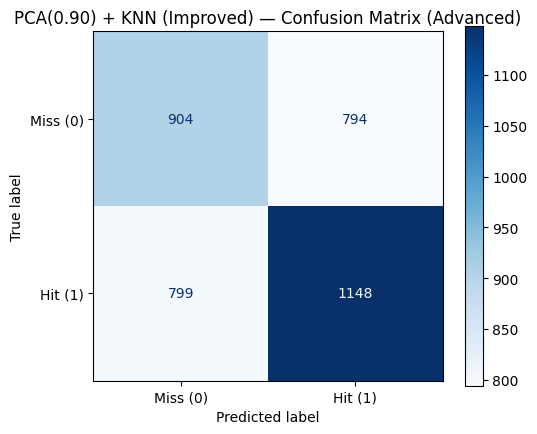

In [5]:
adv = per_ds_results["Advanced"]
cm_array = np.array([
    [adv["confusion_matrix"]["tn"], adv["confusion_matrix"]["fp"]],
    [adv["confusion_matrix"]["fn"], adv["confusion_matrix"]["tp"]],
])
fig_cm = confusion_matrix_figure(
    cm_array,
    title=f"{DISPLAY_NAME} — Confusion Matrix (Advanced)",
)
save_figure(MODEL_SLUG, "confusion_matrix.png", fig_cm)
plt.show()

## 6 — ROC curve + AUC (Advanced fit)

Generated against `predict_proba` (or `decision_function`
where probabilities aren't available). The AUC is the
ranking-quality summary independent of any threshold choice;
Phase 4's threshold-sweep work depends on it.

Test ROC AUC (Advanced): 0.5848


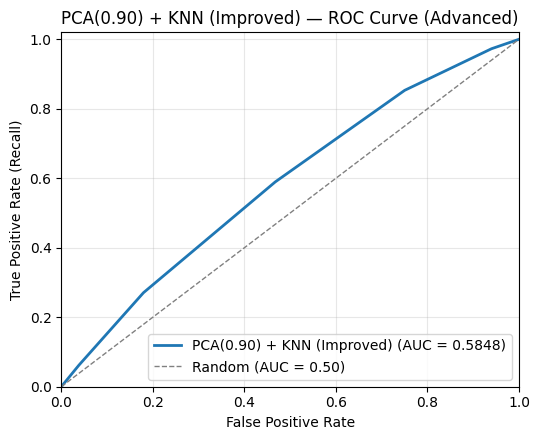

In [6]:
fig_roc, auc = roc_curve_figure(
    y_test, adv["proba_hit"],
    title=f"{DISPLAY_NAME} — ROC Curve (Advanced)",
    model_label=DISPLAY_NAME,
)
save_figure(MODEL_SLUG, "roc_curve.png", fig_roc)
print(f"Test ROC AUC (Advanced): {auc:.4f}")
plt.show()

## 8 — Persist the canonical metrics JSON

One JSON per model, written to
`results/<slug>/metrics.json`. Schema is defined in
`src.train_utils.build_metrics_payload`; the master
comparison notebook reads from here.

In [7]:
extras = {
    "dropped_columns":          list(NUTRITION_COLS),
    "columns_before_drop":      cols_before_drop,
    "columns_after_drop":       cols_after_drop,
    "pca_components_retained":  pca_components_per_dataset,
    "pca_variance_threshold":   PCA_VARIANCE,
    "knn_n_neighbors":          KNN_NEIGHBORS,
    "roc_auc_advanced":         auc,
}

payload = build_metrics_payload(
    model_name=MODEL_NAME,
    display_name=DISPLAY_NAME,
    model_config=MODEL_CONFIG,
    n_train=len(y_train),
    n_test=len(y_test),
    random_state=RANDOM_STATE,
    per_dataset_results=per_ds_results,
    extras=extras,
)
metrics_path = save_metrics(MODEL_SLUG, payload)
print(f"Wrote {metrics_path.relative_to(metrics_path.parent.parent.parent)}")

Wrote results/pca_knn_improved/metrics.json


## 9 — Summary

    **Model:** PCA(0.90) + KNN (Improved)

    - **Test Accuracy / F1:** ~0.5630 / ~0.5904 — a +4.97 pp Acc
  and +3.26 pp F1 recovery over the unfixed version on
  Advanced.
- **Search space expanded 182× / 203×** (1 → 182 components
  on Advanced; 1 → 203 on Baseline).
- **Partial rescue:** still ~4 pp below LR. The residual gap
  is the textbook sparse-binary distance penalty (the original
  theoretical objection). README §4 Lesson #5.

    Run the **master comparison notebook
    (`08_Master_Comparison.ipynb`)** to see this model alongside
    the other six in the side-by-side table.